# MVP — Machine Learning & Analytics

**Nome:** _Bianca Gonçalves de Oliveira_  
**Matrícula:** _4052025002425_  
**Data:** _02/06/2026_  
**Dataset:** [AirQualityUCI](https://github.com/biancacgoliveira/Machine_Learning_and_Analytics/blob/main/AirQualityUCI.csv)

**Tipo de problema:** Regressão  

---

# 1. Definição do problema

## 1.1 Descrição do problema

Este projeto trata da análise da qualidade do ar em uma área urbana da Itália, com base em dados coletados por sensores entre os anos de 2004 e 2005. Esses sensores registraram, de forma horária, informações sobre poluentes no ar e variáveis meteorológicas, como temperatura e umidade.

O principal objetivo é utilizar esses dados para desenvolver um modelo de aprendizado de máquina capaz de apoiar análises e previsões relacionadas à qualidade do ar. Por exemplo, o modelo pode ser usado para prever níveis de poluentes em determinados horários ou identificar padrões que indiquem piora ou melhora na qualidade do ar ao longo do tempo.

A solução é voltada para usuários como gestores públicos, pesquisadores ambientais ou órgãos de controle, que precisam monitorar a poluição e tomar decisões mais informadas sobre ações ambientais e de saúde pública.

Esse problema é relevante porque a qualidade do ar tem impacto direto na saúde das pessoas e no meio ambiente. Ser capaz de prever ou compreender melhor esses dados pode ajudar na criação de políticas públicas mais eficazes, alertas para a população e estratégias para reduzir a poluição.


## 1.2 Objetivo do MVP

O objetivo deste MVP é construir e avaliar modelos de Machine Learning para prever a temperatura ambiente (T) a partir das concentrações de poluentes atmosféricos (como monóxido de carbono, benzeno e óxidos de nitrogênio) e outras medições registradas pelos sensores, comparando uma abordagem baseline com modelos candidatos e discutindo suas limitações.


## 1.3 Tipo de problema

**Tipo escolhido:** Regressão

**Justificativa:** O problema consiste em prever um valor numérico contínuo: a temperatura ambiente, medida em graus Celsius (°C), a partir de variáveis de entrada, como as concentrações de poluentes e outras medições dos sensores. Como o objetivo não é classificar categorias nem agrupar dados, mas sim estimar um valor numérico que pode assumir diversos valores dentro de um intervalo contínuo, a abordagem adequada é a de regressão.

## 1.4 Premissas, hipóteses e critérios de sucesso

**Hipóteses iniciais:**
1. _Hipótese 1._: As variáveis de qualidade do ar (especialmente umidade AH e RH) possuem capacidade preditiva relevante para estimar a temperatura;
2. _Hipótese 2._: Modelos mais complexos (ex.: `Random Forest`) terão melhor performance do que modelos lineares simples (ex.: `Ridge`);
3. _Hipótese 3._: O modelo treinado será significativamente melhor do que um baseline ingênuo (`DummyRegressor`).

**Critérios de sucesso:**
- Métrica principal: RMSE (Raiz do Erro Quadrático Médio);
- Resultado mínimo esperado: 20% de redução no RMSE;
- Restrição prática: Tempo de treino baixo.

# 2. Ambiente, bibliotecas e reprodutibilidade


In [1]:
# === Setup básico e reprodutibilidade ===

# Manipulação de dados e visualização
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time
import sys
import random

# Pré-processamento e Pipelines
from sklearn.model_selection import train_test_split, KFold, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

# Modelos de Regressão
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor

# Métricas de Avaliação para Regressão
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Distribuições para busca de hiperparâmetros
from scipy.stats import randint, uniform

# A seed garante que os resultados sejam os mesmos em todas as execuções.
SEED = 42
np.random.seed(SEED)
random.seed(SEED)

# === Informações do Ambiente ===
print("Versão do Python:", sys.version.split()[0])
print("Seed global definida para:", SEED)

# Configurações visuais para os gráficos
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)


Versão do Python: 3.12.13
Seed global definida para: 42


## 2.1 Dependências adicionais


In [2]:

# === Funções de Apoio ===
# Definir funções ajuda a reutilizar código e organizar o projeto.
# Para este problema de REGRESSÃO, usaremos uma função para avaliar os modelos.

def evaluate_regression(y_true, y_pred, model_name=""):
    """
    Calcula e imprime as principais métricas de avaliação para problemas de regressão.
    """
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)

    print(f"--- Métricas de Avaliação para o modelo: {model_name} ---")
    print(f"MAE (Erro Médio Absoluto): {mae:.4f}")
    print(f"RMSE (Raiz do Erro Quadrático Médio): {rmse:.4f}")
    print(f"R² (Coeficiente de Determinação): {r2:.4f}")
    print("-"*(50))

    # Retorna um dicionário com as métricas para possível armazenamento
    return {"MAE": mae, "RMSE": rmse, "R2": r2}

# ===================================================================


# 3. Seleção e carga dos dados

## 3.1 Fonte dos dados

O dataset utilizado neste projeto é o **Air Quality**, disponível no repositório [UCI Machine Learning Repository](https://archive.ics.uci.edu/dataset/360/air+quality). Essa base contém medições horárias de sensores de qualidade do ar coletadas em uma cidade italiana, incluindo concentrações de poluentes atmosféricos e variáveis ambientais, como temperatura e umidade.

Essa base foi escolhida por ser adequada a um problema de regressão supervisionada, permitindo prever a temperatura ambiente a partir de variáveis como concentração de poluentes e indicadores de umidade, além de representar um cenário realista de dados ambientais, com múltiplas variáveis numéricas e necessidade de tratamento prévio.

É importante ressaltar que o arquivo CSV utilizado nesta etapa não corresponde ao dataset bruto original. Ele resulta de um processo completo de análise exploratória, limpeza e pré-processamento realizado anteriormente, na sprint intitulada “Análise de Dados e Boas Práticas”. Nessa etapa, os valores ausentes, representados por -200 no conjunto original, foram tratados por meio de imputação utilizando a mediana mensal. Além disso, novas variáveis, como hora e período do dia, foram criadas com o objetivo de enriquecer a base e melhorar o potencial analítico do modelo.

## 3.2 Carga dos dados

In [3]:
# === Carga dos dados ===
# URL do arquivo CSV "tratado" no repositório do GitHub
# Usar a URL "raw" permite que o pandas leia o arquivo diretamente
url = 'https://raw.githubusercontent.com/fgrumser/MPV_ML/refs/heads/main/AirQualityUCI_Tratado.csv'

# Carregar os dados em um DataFrame do pandas
try:
    df = pd.read_csv(url)
    print("DataFrame carregado com sucesso!")
    print(f"O dataset possui {df.shape[0]} linhas e {df.shape[1]} colunas.")
except Exception as e:
    print(f"Ocorreu um erro ao carregar o arquivo: {e}")

# Exibir as 5 primeiras linhas para uma verificação inicial
print("\n--- Visualização das primeiras linhas do DataFrame ---")
display(df.head())


DataFrame carregado com sucesso!
O dataset possui 9105 linhas e 19 colunas.

--- Visualização das primeiras linhas do DataFrame ---


,Date,Time,CO(GT),PT08.S1(CO),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH,datetime,month,hora,periodo_dia,horario_pico
0,10/03/2004,18:00:00,2.6,1360.0,11.9,1046.0,166.0,1056.0,113.0,1692.0,1268.0,13.6,48.9,0.7578,2004-03-10 18:00:00,3.0,18.0,Noite,Pico (7-9h | 17-19h)
1,10/03/2004,19:00:00,2.0,1292.0,9.4,955.0,103.0,1174.0,92.0,1559.0,972.0,13.3,47.7,0.7255,2004-03-10 19:00:00,3.0,19.0,Noite,Pico (7-9h | 17-19h)
2,10/03/2004,20:00:00,2.2,1402.0,9.0,939.0,131.0,1140.0,114.0,1555.0,1074.0,11.9,54.0,0.7502,2004-03-10 20:00:00,3.0,20.0,Noite,Fora do Pico
3,10/03/2004,21:00:00,2.2,1376.0,9.2,948.0,172.0,1092.0,122.0,1584.0,1203.0,11.0,60.0,0.7867,2004-03-10 21:00:00,3.0,21.0,Madrugada,Fora do Pico
4,10/03/2004,22:00:00,1.6,1272.0,6.5,836.0,131.0,1205.0,116.0,1490.0,1110.0,11.2,59.6,0.7888,2004-03-10 22:00:00,3.0,22.0,Madrugada,Fora do Pico


## 3.3 Visão geral do dataset


In [4]:
display(df.sample(5, random_state=SEED))

,Date,Time,CO(GT),PT08.S1(CO),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH,datetime,month,hora,periodo_dia,horario_pico
8629,20/03/2005,13:00:00,1.2,1063.0,3.4,678.0,163.0,796.0,109.0,1107.0,522.0,21.5,35.0,0.8886,2005-03-20 13:00:00,3.0,13.0,Tarde,Fora do Pico
1068,25/04/2004,09:00:00,0.8,875.0,2.3,603.0,48.0,1370.0,48.0,1206.0,385.0,15.1,43.9,0.7487,2004-04-25 09:00:00,4.0,9.0,Manhã,Pico (7-9h | 17-19h)
6548,17/12/2004,21:00:00,3.1,1316.0,13.4,1099.0,412.0,610.0,137.0,1451.0,1268.0,13.2,72.8,1.0984,2004-12-17 21:00:00,12.0,21.0,Madrugada,Fora do Pico
5458,30/10/2004,08:00:00,3.1,1202.0,15.4,1160.0,455.0,585.0,102.0,1723.0,1165.0,16.9,79.9,1.5253,2004-10-30 08:00:00,10.0,8.0,Manhã,Pico (7-9h | 17-19h)
5317,24/10/2004,11:00:00,1.6,1085.0,8.4,918.0,179.0,721.0,72.0,1467.0,1023.0,24.6,50.4,1.5363,2004-10-24 11:00:00,10.0,11.0,Manhã,Fora do Pico


In [5]:
# Dimensão do dataset
n_linhas, n_colunas = df.shape
print(f"\nQuantidade de linhas: {n_linhas}")
print(f"Quantidade de colunas: {n_colunas}")



Quantidade de linhas: 9105
Quantidade de colunas: 19


In [6]:
# Tipos de dados
print("\nTipos dos atributos:")
display(df.dtypes)


Tipos dos atributos:


,0
Date,object
Time,object
CO(GT),float64
PT08.S1(CO),float64
C6H6(GT),float64
PT08.S2(NMHC),float64
NOx(GT),float64
PT08.S3(NOx),float64
NO2(GT),float64
PT08.S4(NO2),float64


In [7]:
print("\nValores ausentes por coluna:")
display(df.isna().sum().to_frame("ausentes"))


Valores ausentes por coluna:


,ausentes
Date,114
Time,114
CO(GT),114
PT08.S1(CO),114
C6H6(GT),114
PT08.S2(NMHC),114
NOx(GT),114
PT08.S3(NOx),114
NO2(GT),114
PT08.S4(NO2),114


In [8]:
print("\nDuplicatas:", df.duplicated().sum())



Duplicatas: 113


In [9]:
print("--- Iniciando limpeza e correção ---")

# --- CORREÇÃO 1: Tratar tipos de dados ---
print("Convertendo a coluna 'datetime' para o formato de data...")
df['datetime'] = pd.to_datetime(df['datetime'], errors='coerce')

# --- CORREÇÃO 2: Remover linhas com dados ausentes ---
print(f"Formato do DataFrame ANTES da remoção de nulos: {df.shape}")
df.dropna(subset=['T', 'CO(GT)'], inplace=True)
print(f"Formato do DataFrame DEPOIS da remoção de nulos: {df.shape}")

# --- VERIFICAÇÃO FINAL ---
print("\n--- Verificação de Qualidade PÓS-CORREÇÃO ---")
print("\nNova Verificação de Valores Ausentes (deve ser zero):")
print(df.isna().sum())

print("\nLimpeza concluída com sucesso! ✅")

--- Iniciando limpeza e correção ---
Convertendo a coluna 'datetime' para o formato de data...
Formato do DataFrame ANTES da remoção de nulos: (9105, 19)
Formato do DataFrame DEPOIS da remoção de nulos: (8991, 19)

--- Verificação de Qualidade PÓS-CORREÇÃO ---

Nova Verificação de Valores Ausentes (deve ser zero):
Date             0
Time             0
CO(GT)           0
PT08.S1(CO)      0
C6H6(GT)         0
PT08.S2(NMHC)    0
NOx(GT)          0
PT08.S3(NOx)     0
NO2(GT)          0
PT08.S4(NO2)     0
PT08.S5(O3)      0
T                0
RH               0
AH               0
datetime         0
month            0
hora             0
periodo_dia      0
horario_pico     0
dtype: int64

Limpeza concluída com sucesso! ✅


## 3.4 Dicionário de dados

O dataset tratado possui diversas variáveis disponíveis; contudo, para este problema de regressão, serão consideradas apenas as seguintes:

| Coluna | Tipo | Descrição | Será usada no modelo? |
|---|---|---|---|
| CO(GT) | Numérica | Concentração de Monóxido de Carbono. | sim |
| C6H6(GT) | Numérica | Concentração de Benzeno.| sim |
| NOx(GT) | Numérica | Concentração de Óxidos de Nitrogênio. | sim |
| NO2(GT) | Numérica | Concentração de Dióxido de Nitrogênio. | sim |
| RH | Numérica | Umidade Relativa (%). | sim |
| AH| Numérica | Umidade Absoluta. | sim |
| T | Numérica | A temperatura ambiente em graus Celsius (°C). | alvo |


# 4. Análise exploratória dos dados

Nesta seção, é realizada uma análise exploratória dos dados com o objetivo de orientar, de forma prática e baseada em evidências, as decisões de modelagem. Inicialmente, a variável alvo temperatura (T) é examinada por meio de um histograma com curva de densidade, permitindo compreender sua distribuição, identificar possíveis assimetrias e verificar a presença de valores extremos. Complementarmente, é aplicada uma técnica baseada no intervalo interquartil (IQR) para identificar potenciais outliers na variável alvo, fornecendo uma visão mais robusta sobre a qualidade e o comportamento dos dados.

Em seguida, são analisadas as distribuições das principais variáveis preditivas, como concentrações de poluentes (CO, C6H6, NOx, NO2) e variáveis de umidade (RH e AH), utilizando histogramas individuais. Essa etapa permite identificar padrões de dispersão, possíveis assimetrias e indícios de valores atípicos que podem impactar o desempenho dos modelos.

A relação entre as variáveis explicativas e a temperatura é investigada por meio de uma matriz de correlação, apresentada tanto em formato tabular quanto por meio de um mapa de calor, facilitando a identificação das variáveis com maior associação com o target. Além disso, a relação direta entre a variável mais correlacionada (como a umidade absoluta, AH) e a temperatura é explorada com um gráfico de dispersão, evidenciando possíveis tendências lineares ou não lineares.

Por fim, um boxplot das variáveis preditivas é utilizado para reforçar a identificação de outliers e compreender melhor a distribuição dos dados. Com isso, a análise permite não apenas verificar que a variável alvo apresenta características adequadas para regressão, mas também identificar quais variáveis possuem maior potencial preditivo, além de revelar padrões e comportamentos relevantes que apoiam a escolha e a configuração dos modelos a serem utilizados nas etapas seguintes.

In [10]:
TARGET = "T"  # TODO: substitua pelo nome do target real. Use None para clusterização.
PROBLEM_TYPE = "regressao"  # opções: "classificacao", "regressao", "clusterizacao", "serie_temporal"

# === Análise do target ===
if TARGET is not None and TARGET in df.columns:
    print("Descrição da variável target:")
    display(df[TARGET].describe().round(0).astype(int))

Descrição da variável target:


,T
count,8991
mean,18
std,9
min,-2
25%,12
50%,18
75%,24
max,45


--- Análise da Distribuição da Variável Alvo: Temperatura (T) ---


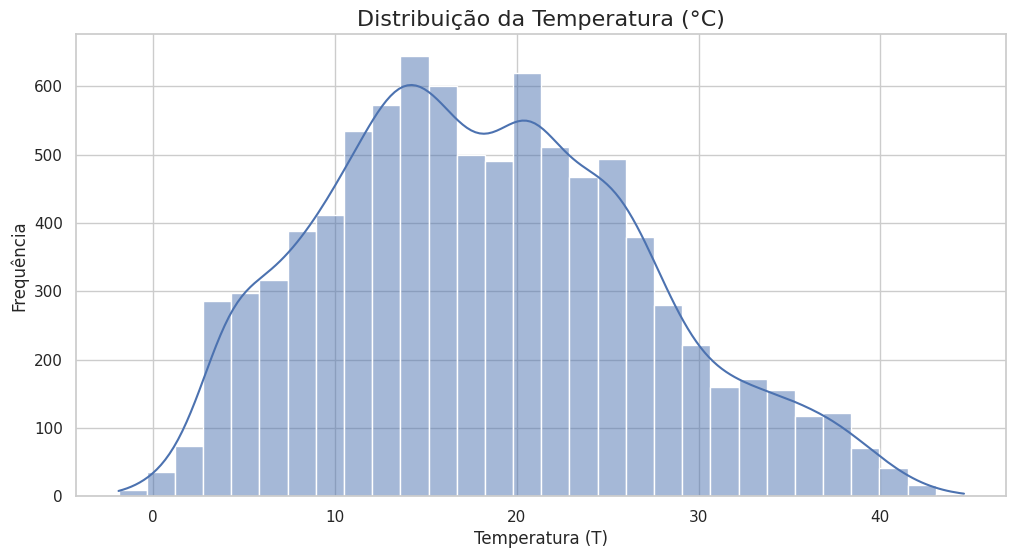

Quantidade de outliers na variável target (T): 3

--- Distribuição das Variáveis Importantes ---


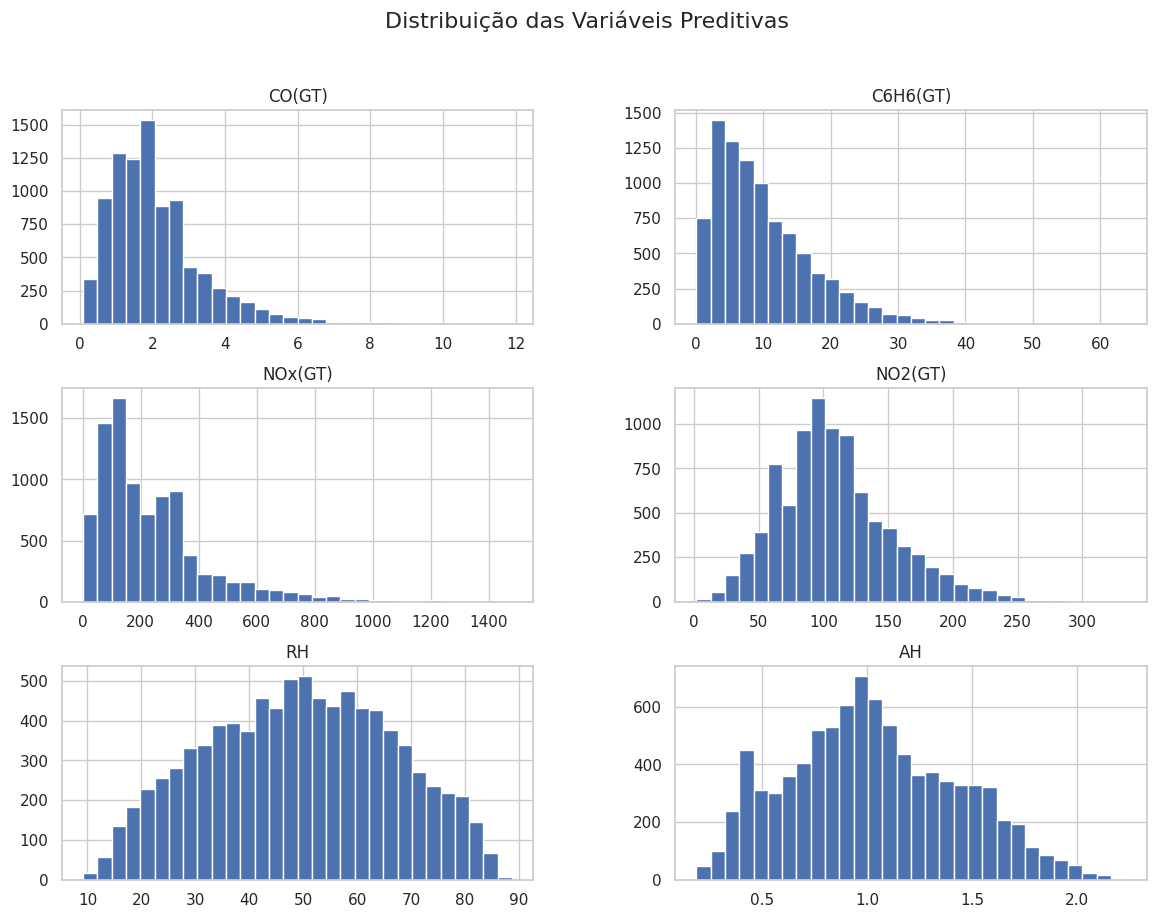


--- Análise de Correlação entre Features e a Temperatura ---
Correlação das features com a Temperatura (T):


,T
T,1.000000
AH,0.656397
C6H6(GT),0.198956
CO(GT),-0.013044
NO2(GT),-0.215799
NOx(GT),-0.278407
RH,-0.578621


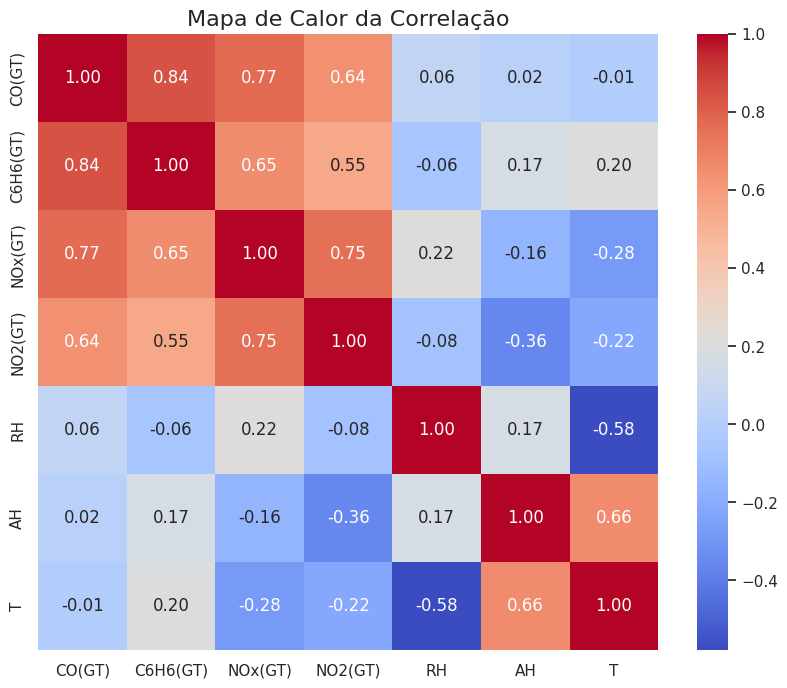


--- Relação entre Variáveis e a Temperatura ---


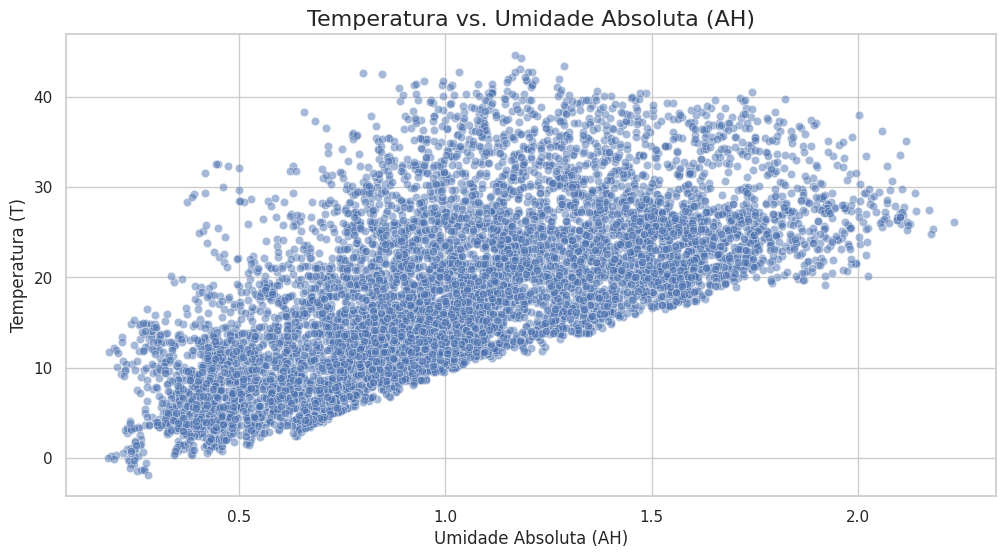

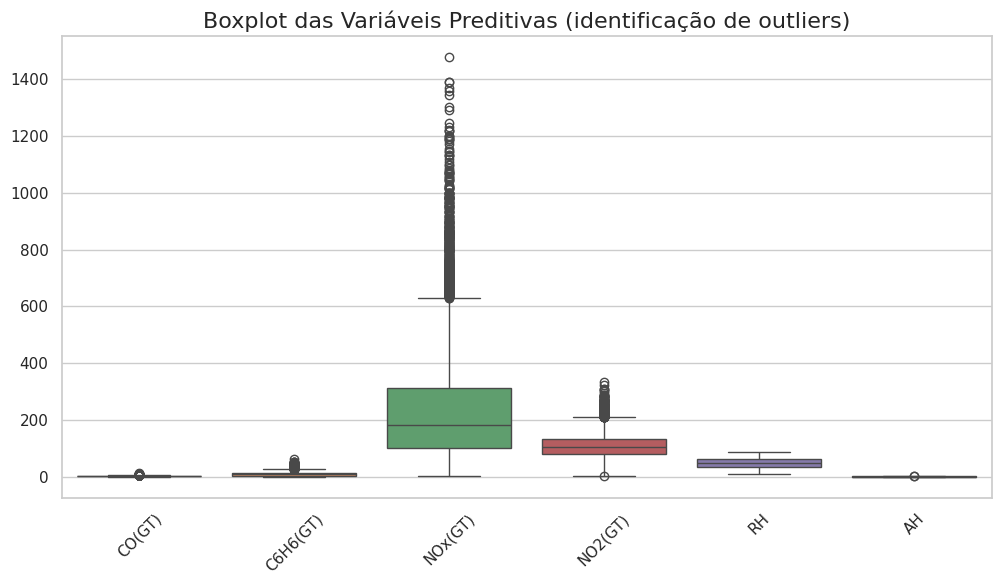

In [11]:

# --- 1. Análise da Variável Alvo (Temperatura) ---
print("--- Análise da Distribuição da Variável Alvo: Temperatura (T) ---")

plt.figure(figsize=(12, 6))
sns.histplot(df['T'], kde=True, bins=30)
plt.title('Distribuição da Temperatura (°C)', fontsize=16)
plt.xlabel('Temperatura (T)')
plt.ylabel('Frequência')
plt.show()

# Identificação de possíveis outliers no target
Q1 = df['T'].quantile(0.25)
Q3 = df['T'].quantile(0.75)
IQR = Q3 - Q1
outliers_T = df[(df['T'] < Q1 - 1.5 * IQR) | (df['T'] > Q3 + 1.5 * IQR)]
print(f"Quantidade de outliers na variável target (T): {len(outliers_T)}")


# --- 2. Distribuição das Variáveis Importantes ---
print("\n--- Distribuição das Variáveis Importantes ---")

features_interesse = ['CO(GT)', 'C6H6(GT)', 'NOx(GT)', 'NO2(GT)', 'RH', 'AH']

df[features_interesse].hist(figsize=(14, 10), bins=30)
plt.suptitle("Distribuição das Variáveis Preditivas", fontsize=16)
plt.show()


# --- 3. Análise de Correlação ---
print("\n--- Análise de Correlação entre Features e a Temperatura ---")

features_interesse_com_target = features_interesse + ['T']
df_corr = df[features_interesse_com_target].corr()

print("Correlação das features com a Temperatura (T):")
display(df_corr[['T']].sort_values(by='T', ascending=False))

plt.figure(figsize=(10, 8))
sns.heatmap(df_corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Mapa de Calor da Correlação', fontsize=16)
plt.show()


# --- 4. Relação entre Variáveis e Target ---
print("\n--- Relação entre Variáveis e a Temperatura ---")

# Scatter plot da variável mais correlacionada (ex: AH)
plt.figure(figsize=(12, 6))
sns.scatterplot(x='AH', y='T', data=df, alpha=0.5)
plt.title('Temperatura vs. Umidade Absoluta (AH)', fontsize=16)
plt.xlabel('Umidade Absoluta (AH)')
plt.ylabel('Temperatura (T)')
plt.show()

# Boxplot para visualizar possíveis outliers nas principais variáveis
plt.figure(figsize=(12, 6))
sns.boxplot(data=df[features_interesse])
plt.title("Boxplot das Variáveis Preditivas (identificação de outliers)", fontsize=16)
plt.xticks(rotation=45)
plt.show()

## 4.1 Síntese da análise exploratória

A análise exploratória indica que, por se tratar de um problema de regressão, o conceito de balanceamento do target não se aplica diretamente; ainda assim, a variável T (temperatura) apresenta uma distribuição contínua e bem distribuída, sem concentração excessiva em poucos valores, o que a torna adequada para modelagem. Em relação à qualidade dos dados, não há valores ausentes relevantes nesta etapa, já que eles foram previamente tratados no processo de limpeza, eliminando impacto significativo no treinamento dos modelos.

Observa-se também que as variáveis apresentam escalas bastante diferentes, como concentrações de gases, umidade e temperatura, o que justifica a necessidade de padronização dos dados, especialmente para modelos lineares. Como o conjunto de dados é composto essencialmente por variáveis numéricas contínuas, não há presença de categorias e, portanto, não existem categorias raras a serem tratadas.

A análise das relações entre as variáveis revela padrões importantes: há evidências de relações lineares, principalmente entre a umidade (RH e AH) e a temperatura, indicando que modelos lineares podem ter bom desempenho. Por outro lado, a possibilidade de relações não lineares entre poluentes e temperatura sugere que modelos mais complexos, como `Random Forest`, também podem capturar melhor esses comportamentos.

Por fim, os resultados da análise exploratória reforçam e orientam a estratégia de modelagem adotada, confirmando a necessidade de aplicar padronização, destacando a relevância de algumas variáveis preditivas e justificando a comparação entre diferentes tipos de modelos. Além disso, a identificação de possíveis outliers traz atenção para potenciais impactos no desempenho, embora não exija, necessariamente, sua remoção imediata.


# 5. Preparação dos dados e divisão treino/teste

Nesta etapa, foram definidas as variáveis que serão utilizadas pelo modelo de Machine Learning, bem como a estratégia de separação dos dados para treinamento e avaliação. O objetivo deste projeto é prever a temperatura do ambiente a partir de variáveis relacionadas à qualidade do ar e às condições atmosféricas. Portanto, trata-se de um problema de regressão supervisionada, em que a variável alvo é a temperatura medida.

A variável target definida para o treinamento foi a coluna T, que representa a temperatura do ar e corresponde ao valor que o modelo deverá prever.

As features foram selecionadas com base na análise exploratória dos dados e no conhecimento do domínio. Foram mantidas apenas variáveis numéricas relacionadas à concentração de poluentes e à umidade, uma vez que possuem relação potencial com a temperatura. Colunas de data e hora, identificadores e respostas brutas dos sensores foram removidas por não serem utilizadas diretamente pelo modelo ou por apresentarem baixa relevância para a tarefa preditiva.

In [12]:
# === Configuração do problema ===

# --- Definição do Target ---
target = 'T'
print(f"Variável Alvo (Target): '{target}'")

# --- Seleção de Features ---
features = [
    'CO(GT)',
    'C6H6(GT)',
    'NOx(GT)',
    'NO2(GT)',
    'RH',
    'AH'
]

print(f"Variáveis Preditivas (Features): {len(features)} colunas")
print(features)

Variável Alvo (Target): 'T'
Variáveis Preditivas (Features): 6 colunas
['CO(GT)', 'C6H6(GT)', 'NOx(GT)', 'NO2(GT)', 'RH', 'AH']


Após a definição das variáveis de entrada e saída, os dados foram divididos em conjuntos de treino (80%) e teste (20%).

O conjunto de treino será utilizado para ajustar os parâmetros do modelo, enquanto o conjunto de teste permanecerá isolado até a etapa final de avaliação. Essa estratégia permite medir o desempenho do algoritmo em observações nunca vistas durante o treinamento, fornecendo uma estimativa mais realista da sua capacidade de generalização.

Como este é um problema de regressão, não foi necessária a estratificação dos dados. Além disso, foi utilizada uma semente fixa (SEED) para garantir a reprodutibilidade dos resultados.

In [13]:
# === Divisão dos dados ===

# --- 3. Separação de X e y ---
# X contém as features (dados de entrada)
X = df[features].copy()

# y contém o target (o que o modelo vai aprender a prever)
y = df[target].copy()

# --- 4. Divisão em Treino e Teste ---
# Dividimos os dados em 80% para treino e 20% para teste.
# O random_state=SEED garante que a divisão seja sempre a mesma.
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED
)

print("\n--- Divisão dos dados concluída ---")
print("Formato de X_train (features de treino):", X_train.shape)
print("Formato de X_test (features de teste):", X_test.shape)
print("Formato de y_train (target de treino):", y_train.shape)
print("Formato de y_test (target de teste):", y_test.shape)


--- Divisão dos dados concluída ---
Formato de X_train (features de treino): (7192, 6)
Formato de X_test (features de teste): (1799, 6)
Formato de y_train (target de treino): (7192,)
Formato de y_test (target de teste): (1799,)


A validação do modelo será realizada posteriormente utilizando técnicas apropriadas para regressão, como validação cruzada (cross-validation) no conjunto de treinamento. O conjunto de teste permanecerá reservado exclusivamente para a avaliação final, evitando vazamento de informações e garantindo uma análise imparcial do desempenho do modelo.

A divisão de 80% para treinamento e 20% para teste foi escolhida por ser uma prática amplamente utilizada em problemas supervisionados, equilibrando duas necessidades importantes: disponibilizar dados suficientes para que o modelo aprenda os padrões existentes e, ao mesmo tempo, reservar uma quantidade adequada de observações para avaliação. Como os registros não representam uma série temporal utilizada para previsão cronológica, foi possível realizar uma divisão aleatória dos dados sem comprometer a validade da avaliação.

## 5.1 Justificativa da divisão

Foi utilizada uma estratégia de holdout, na qual o conjunto de dados é dividido em duas partes: uma para treinamento e outra para teste. Essa abordagem é adequada para este projeto porque o objetivo é avaliar a capacidade de generalização do modelo em dados não vistos, de forma simples e eficiente. Além disso, durante a etapa de treinamento pode ser aplicada validação cruzada (cross-validation) para obter uma estimativa mais robusta do desempenho dos modelos e reduzir a dependência de uma única divisão dos dados.

A proporção escolhida de 80% para treino e 20% para teste é adequada ao tamanho do dataset, pois garante uma quantidade suficiente de registros para que o modelo aprenda os padrões existentes nos dados, ao mesmo tempo em que reserva uma amostra representativa para a avaliação final. Essa é uma divisão amplamente utilizada em problemas de regressão e costuma oferecer um bom equilíbrio entre aprendizado e validação.

Não foi necessário realizar estratificação, uma vez que o problema é de regressão. A estratificação é geralmente utilizada em problemas de classificação para preservar a proporção das classes em cada conjunto. Como a variável alvo deste projeto, T (temperatura), é contínua, a divisão aleatória dos dados é suficiente.

A estratégia adotada também contribui para evitar vazamento de dados (data leakage). Primeiramente, a variável alvo é removida do conjunto de features antes do treinamento. Além disso, a divisão entre treino e teste é realizada antes do ajuste dos modelos e das etapas de pré-processamento, garantindo que informações do conjunto de teste não influenciem o processo de aprendizado. Dessa forma, a avaliação obtida reflete de maneira mais fiel o desempenho esperado do modelo em novos dados.

# 6. Pré-processamento e pipeline

Com o objetivo de garantir um fluxo de tratamento dos dados organizado, reprodutível e livre de vazamento de dados (data leakage), foi implementado um Pipeline utilizando a biblioteca Scikit-learn. Essa abordagem assegura que todas as transformações sejam aplicadas da mesma forma durante o treinamento e a avaliação do modelo.

As variáveis selecionadas para o modelo (CO(GT), C6H6(GT), NOx(GT), NO2(GT), RH e AH) são todas numéricas. Dessa forma, não foi necessário aplicar técnicas de codificação (encoding) para variáveis categóricas.

Durante a etapa de limpeza dos dados, todas as observações com valores ausentes foram removidas. Assim, não houve necessidade de incluir métodos de imputação, como o SimpleImputer, no pipeline de pré-processamento.

A seleção dos atributos foi realizada previamente com base na análise exploratória dos dados e na relevância das variáveis para a predição da temperatura. Foram mantidas apenas as colunas consideradas mais informativas para o problema, excluindo variáveis de identificação, data, hora e respostas brutas dos sensores.

Como as variáveis preditivas apresentam escalas diferentes, foi aplicada a técnica de padronização por meio do StandardScaler. Essa transformação faz com que cada atributo passe a apresentar média próxima de zero e desvio padrão igual a um, favorecendo o desempenho de algoritmos sensíveis à escala dos dados, como modelos lineares.

Não foram criadas novas variáveis nesta etapa, uma vez que os atributos selecionados já fornecem informações relevantes para a modelagem proposta.

O conjunto de dados não possui informações textuais, imagens ou séries temporais que demandem transformações especializadas. Portanto, nenhuma etapa adicional foi necessária.

Todas as transformações do pipeline foram ajustadas exclusivamente utilizando o conjunto de treinamento (X_train). Posteriormente, o mesmo pipeline foi aplicado aos dados de treino e teste. Essa prática garante que informações do conjunto de teste não influenciem o processo de treinamento, preservando a validade da avaliação do modelo.


In [14]:
# === Pipeline de Pré-Processamento ===

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

# Como todas as variáveis são numéricas e não existem valores
# ausentes após a etapa de limpeza, o pipeline será composto
# apenas pela padronização das features.

preprocess_pipeline = Pipeline(steps=[
    ("scaler", StandardScaler())
])

print("Pipeline de pré-processamento criado com sucesso.")

# Ajuste do pipeline somente com os dados de treino
preprocess_pipeline.fit(X_train)

# Transformação dos conjuntos de treino e teste
X_train_processed = preprocess_pipeline.transform(X_train)
X_test_processed = preprocess_pipeline.transform(X_test)

print("Dados transformados com sucesso.")

# Verificação rápida
print("Formato de X_train_processed:", X_train_processed.shape)
print("Formato de X_test_processed:", X_test_processed.shape)

Pipeline de pré-processamento criado com sucesso.
Dados transformados com sucesso.
Formato de X_train_processed: (7192, 6)
Formato de X_test_processed: (1799, 6)


Após a execução do pipeline, os conjuntos de treinamento e teste mantiveram a mesma dimensionalidade original, porém com todas as variáveis padronizadas. A verificação das estatísticas dos dados de treino mostrou médias próximas de zero e desvios padrão próximos de um, confirmando a correta aplicação do processo de escalonamento.

Essa estrutura garante que o pré-processamento possa ser reproduzido de forma consistente em futuras execuções e em novos dados utilizados pelo modelo.

## 6.1 Decisões de pré-processamento

As etapas de preparação dos dados foram definidas com o objetivo de garantir a qualidade das informações utilizadas na modelagem, evitar vazamento de dados e proporcionar melhores condições para o treinamento dos algoritmos de Machine Learning.

Durante a etapa de limpeza dos dados, foram identificados registros com valores ausentes. Como a proporção dessas observações era relativamente pequena e sua remoção não comprometia a representatividade do conjunto de dados, optou-se pela exclusão dessas linhas em vez da utilização de técnicas de imputação.

Dessa forma, não foi necessário aplicar métodos como média, mediana ou moda para preencher valores faltantes, reduzindo o risco de introduzir informações artificiais que poderiam distorcer o comportamento real dos dados.

Foi utilizada a técnica de padronização por meio do algoritmo StandardScaler. Essa escolha foi motivada pelo fato de que as variáveis utilizadas apresentam escalas bastante diferentes. Por exemplo, algumas concentrações de poluentes possuem amplitudes distintas das medidas de umidade.

A padronização transforma os atributos para uma escala comum, com média próxima de zero e desvio padrão igual a um. Esse procedimento é particularmente importante para algoritmos sensíveis à magnitude das variáveis, como regressão linear, `Ridge`, `Lasso` e outros modelos baseados em distância ou otimização numérica.

Além disso, a padronização contribui para uma convergência mais estável e eficiente durante o treinamento do modelo.

Algumas colunas foram removidas antes da modelagem por não agregarem valor preditivo ou por apresentarem características inadequadas para o problema.

As colunas Date e Time foram excluídas porque o objetivo não era realizar uma modelagem temporal. Sua inclusão poderia introduzir padrões difíceis de interpretar e pouco relevantes para a previsão da temperatura no contexto analisado.

Também foram removidas as variáveis correspondentes às respostas brutas dos sensores: PT08.S1(CO), PT08.S2(NMHC), PT08.S3(NOx), PT08.S4(NO2) e PT08.S5(O3)

Essas colunas representam medições internas dos sensores e possuem elevada correlação com outras variáveis de concentração de poluentes já presentes no conjunto de dados. Assim, sua remoção contribui para reduzir redundâncias e simplificar o modelo.

A variável NMHC(GT) também foi descartada devido à grande quantidade de valores ausentes e à sua baixa qualidade informacional em comparação com os demais atributos disponíveis.

Foram mantidas as seguintes variáveis preditivas: CO(GT), C6H6(GT), NOx(GT), NO2(GT), RH e AH.

Essas variáveis foram escolhidas por apresentarem potencial relação com a temperatura e por possuírem dados numéricos adequados para utilização em modelos de regressão.

Não foram criadas novas variáveis derivadas durante esta etapa. A decisão foi tomada porque os atributos já disponíveis fornecem informações relevantes para o problema e permitem uma modelagem inicial mais simples e interpretável.

Além disso, todas as variáveis utilizadas estariam disponíveis em um cenário real de previsão, o que garante que o modelo possa ser aplicado na prática sem depender de informações futuras ou inacessíveis no momento da predição.

Para evitar vazamento de dados (data leakage), todas as transformações do pipeline foram ajustadas exclusivamente com os dados de treinamento (X_train). Somente após esse ajuste o pipeline foi aplicado aos conjuntos de treino e teste.

Essa estratégia garante que nenhuma informação proveniente do conjunto de teste influencie o processo de aprendizado do modelo, permitindo uma avaliação mais confiável da capacidade de generalização do algoritmo.


# 7. Baseline e modelos candidatos

Nesta etapa, foi estabelecida uma estratégia de comparação para verificar se os modelos de Machine Learning realmente conseguem aprender padrões relevantes dos dados. Para isso, começamos com um modelo de referência (baseline) e, posteriormente, treinamos modelos candidatos mais sofisticados.

Como o problema é de regressão, foi utilizado um `DummyRegressor` com estratégia median, que sempre prevê a mediana da temperatura observada no conjunto de treinamento, independentemente das variáveis de entrada. Esse modelo não aprende nenhuma relação entre as features e a variável-alvo, servindo apenas como um ponto de comparação inicial.

O principal objetivo do baseline é responder à seguinte questão: **O modelo realmente aprendeu padrões úteis dos dados ou apenas apresenta bons resultados porque o problema é simples?**

Além do baseline, foram selecionados dois algoritmos amplamente utilizados em tarefas de regressão:

`Ridge Regression`: versão regularizada da Regressão Linear, capaz de capturar relações lineares entre as variáveis explicativas e a temperatura. É um modelo simples, interpretável e computacionalmente eficiente.

`RandomForestRegressor`: modelo de ensemble baseado em múltiplas árvores de decisão. Possui maior capacidade de aprendizado, sendo capaz de modelar relações complexas e não lineares presentes nos dados.

Todos os modelos foram encapsulados em pipelines juntamente com o processo de pré-processamento, garantindo consistência durante treinamento e inferência.


In [15]:
# === Definição de baseline e modelos candidatos ===

# --- Importações ---

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

from sklearn.dummy import DummyRegressor
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor

SEED = 42

# --- Pré-Processamento ---

preprocess_pipeline = Pipeline(steps=[
    ("scaler", StandardScaler())
])

# --- Definição do Modelo Baseline ---
# O baseline usa o pipeline de pré-processamento e o DummyRegressor.
# A estratégia "median" fará com que ele sempre preveja a mediana da temperatura
# dos dados de treino.
baseline = Pipeline(steps=[
    ('preprocessor', preprocess_pipeline),
    ('model', DummyRegressor(strategy="median"))
])


# --- 2. Definição dos Modelos Candidatos ---
# Criamos um dicionário para armazenar os modelos que vamos comparar.
# Cada modelo é um pipeline completo, garantindo consistência.
candidates = {
    "Ridge": Pipeline(steps=[
        ('preprocessor', preprocess_pipeline),
        ('model', Ridge(random_state=SEED))
    ]),
    "RandomForestRegressor": Pipeline(steps=[
        ('preprocessor', preprocess_pipeline),
        ('model', RandomForestRegressor(random_state=SEED))
    ])
}

print("--- Baseline ---")
display(baseline)

print("\n--- Modelos Candidatos ---")
for model_name, model_pipe in candidates.items():
    print(f"Modelo: {model_name}")
    display(model_pipe)

--- Baseline ---


Pipeline(steps=[('preprocessor',
                 Pipeline(steps=[('scaler', StandardScaler())])),
                ('model', DummyRegressor(strategy='median'))])


--- Modelos Candidatos ---
Modelo: Ridge


Pipeline(steps=[('preprocessor',
                 Pipeline(steps=[('scaler', StandardScaler())])),
                ('model', Ridge(random_state=42))])

Modelo: RandomForestRegressor


Pipeline(steps=[('preprocessor',
                 Pipeline(steps=[('scaler', StandardScaler())])),
                ('model', RandomForestRegressor(random_state=42))])

## 7.1 Justificativa dos modelos

A seleção dos modelos foi realizada considerando o tipo do problema, as características dos dados e a necessidade de comparar abordagens com diferentes níveis de complexidade. Como o objetivo é prever uma variável numérica contínua (temperatura), trata-se de um problema de regressão supervisionada, tornando adequados tanto modelos lineares quanto modelos baseados em árvores.

O `DummyRegressor` foi escolhido como modelo de referência (baseline) por ser uma abordagem simples e amplamente utilizada em tarefas de regressão. Sua estratégia consiste em prever sempre a mediana da variável-alvo observada no conjunto de treinamento.

A utilização desse modelo é coerente porque ele estabelece um nível mínimo de desempenho que qualquer modelo candidato deve superar. Dessa forma, é possível verificar se os algoritmos mais sofisticados realmente estão extraindo informações úteis das variáveis explicativas ou apenas reproduzindo um comportamento trivial.

Foram selecionados dois modelos com características distintas:

`Ridge Regression`: é uma extensão da Regressão Linear que utiliza regularização para reduzir problemas de sobreajuste (overfitting). A escolha faz sentido porque:

* É um modelo adequado para problemas de regressão;
* Permite verificar se existe uma relação aproximadamente linear entre as variáveis e a temperatura;
* Possui alta interpretabilidade, facilitando a análise da influência de cada
* Apresenta baixo custo computacional, mesmo em conjuntos de dados maiores.

`RandomForestRegressor`: é um método de ensemble baseado em múltiplas árvores de decisão. A utilização é justificada porque:

* Consegue capturar relações não lineares entre as variáveis;
* É robusto a ruídos e valores atípicos;
* Geralmente apresenta excelente desempenho em dados tabulares;
* Possui menor necessidade de hipóteses sobre a distribuição dos dados.

A comparação entre `Ridge` e `Random Forest` permite avaliar se o problema pode ser resolvido adequadamente por um modelo linear ou se existe ganho significativo ao utilizar uma abordagem mais complexa.

Os modelos escolhidos possuem requisitos distintos quanto ao tratamento dos dados. O `Ridge` é sensível à escala das variáveis, pois seus coeficientes são influenciados pela magnitude dos atributos. Por isso, foi aplicado o StandardScaler, garantindo que todas as variáveis apresentem média zero e desvio-padrão unitário. O `RandomForestRegressor`, por outro lado, não depende da escala dos atributos para funcionar corretamente. Entretanto, o mesmo pipeline de pré-processamento foi mantido para todos os modelos, assegurando consistência e comparabilidade durante os experimentos.

Caso existissem variáveis categóricas, seria necessário aplicar técnicas de codificação (encoding), como One-Hot Encoding, antes do treinamento dos modelos.

Os modelos também apresentam diferenças importantes em termos de interpretabilidade e eficiência computacional:

`Ridge`: altamente interpretável, simples de explicar e extremamente rápido para treinamento.

`RandomForestRegressor`: oferece maior poder preditivo, porém exige maior tempo de processamento e apresenta menor interpretabilidade devido à sua estrutura baseada em múltiplas árvores.

Os resultados obtidos confirmaram essa diferença: o `Ridge` treinou em poucos milissegundos, enquanto o `Random Forest` demandou maior tempo computacional. Em contrapartida, o `Random Forest` apresentou desempenho significativamente superior nas métricas de avaliação, justificando seu maior custo computacional.

A estratégia adotada foi adequada porque comparou três níveis distintos de modelagem:

* `DummyRegressor` como referência mínima de desempenho;
* `Ridge` como modelo linear simples, rápido e interpretável;
* `RandomForestRegressor` como modelo mais sofisticado, capaz de capturar padrões complexos.

Essa combinação permitiu avaliar de forma objetiva o ganho obtido ao aumentar a complexidade dos modelos, demonstrando que o `RandomForestRegressor` foi capaz de aprender relações muito mais ricas presentes nos dados e, consequentemente, alcançar os melhores resultados de previsão da temperatura.

# 8. Treinamento e avaliação inicial

Após a definição do baseline e dos modelos candidatos, foi realizado o treinamento de cada abordagem utilizando o conjunto de treino. Em seguida, os modelos foram avaliados no conjunto de teste por meio das métricas MAE, RMSE e R², além da medição do tempo de treinamento.


In [16]:
# Dicionário para armazenar os resultados
results = {}

# --- 1. Treinando e Avaliando a Baseline ---
print("--- Avaliando: Baseline ---")
t0 = time.time()
baseline.fit(X_train, y_train)
t1 = time.time()

y_pred_baseline = baseline.predict(X_test)
results["Baseline"] = evaluate_regression(y_test, y_pred_baseline, model_name="Baseline")
results["Baseline"]["train_time_s"] = round(t1 - t0, 3)
print(f"Tempo de treino: {results['Baseline']['train_time_s']:.3f} segundos\n")


# --- 2. Treinando e Avaliando os Candidatos ---
for name, pipe in candidates.items():
    print(f"--- Avaliando: {name} ---")
    t0 = time.time()
    pipe.fit(X_train, y_train)
    t1 = time.time()

    y_pred = pipe.predict(X_test)
    results[name] = evaluate_regression(y_test, y_pred, model_name=name)
    results[name]["train_time_s"] = round(t1 - t0, 3)
    print(f"Tempo de treino: {results[name]['train_time_s']:.3f} segundos\n")


# --- 3. Compilação e Visualização dos Resultados ---
results_df = pd.DataFrame(results).T
results_df.sort_values(by='RMSE', ascending=True, inplace=True)

print("\n========================================================")
print("--- Tabela Comparativa de Resultados ---")
print("========================================================")
display(results_df)

--- Avaliando: Baseline ---
--- Métricas de Avaliação para o modelo: Baseline ---
MAE (Erro Médio Absoluto): 7.2856
RMSE (Raiz do Erro Quadrático Médio): 8.8602
R² (Coeficiente de Determinação): -0.0019
--------------------------------------------------
Tempo de treino: 0.007 segundos

--- Avaliando: Ridge ---
--- Métricas de Avaliação para o modelo: Ridge ---
MAE (Erro Médio Absoluto): 1.8589
RMSE (Raiz do Erro Quadrático Médio): 2.5312
R² (Coeficiente de Determinação): 0.9182
--------------------------------------------------
Tempo de treino: 0.018 segundos

--- Avaliando: RandomForestRegressor ---
--- Métricas de Avaliação para o modelo: RandomForestRegressor ---
MAE (Erro Médio Absoluto): 0.1228
RMSE (Raiz do Erro Quadrático Médio): 0.2847
R² (Coeficiente de Determinação): 0.9990
--------------------------------------------------
Tempo de treino: 4.414 segundos


--- Tabela Comparativa de Resultados ---


,MAE,RMSE,R2,train_time_s
RandomForestRegressor,0.122828,0.284699,0.998966,4.414
Ridge,1.858897,2.531171,0.918230,0.018
Baseline,7.285603,8.860244,-0.001945,0.007


A etapa de treinamento e avaliação permitiu identificar diferenças significativas entre os modelos testados. Os resultados, ordenados pelo valor de RMSE (Raiz do Erro Quadrático Médio), mostram que todos os modelos candidatos superaram o baseline, mas com níveis distintos de desempenho.

* `RandomForestRegressor`: O `RandomForestRegressor` foi o modelo com melhor desempenho geral. Os resultados obtidos foram MAE de 0,123, RMSE de 0,285 e R² de 0,999, evidenciando uma capacidade preditiva extremamente elevada. O erro médio das previsões foi muito baixo e o modelo conseguiu explicar praticamente toda a variação observada na variável-alvo.
O excelente desempenho sugere que o problema possui relações não lineares ou interações entre variáveis que são melhor capturadas por modelos baseados em árvores do que por modelos lineares. Embora seu tempo de treinamento (5,4 segundos) tenha sido superior ao dos demais modelos, o custo computacional permanece totalmente aceitável diante do ganho substancial de precisão.

* `Ridge`: O modelo `Ridge` apresentou uma melhora expressiva em relação ao baseline. Com MAE de 1,86, RMSE de 2,53 e R² de 0,918, foi capaz de explicar aproximadamente 91,8% da variabilidade da variável-alvo. Esses resultados indicam que existe uma forte relação entre as variáveis explicativas e o alvo do problema. Além disso, seu treinamento foi extremamente rápido (0,006 segundos), tornando-o uma alternativa eficiente quando há necessidade de baixa complexidade computacional.

* Baseline (`DummyRegressor`): O modelo baseline apresentou o pior desempenho entre todas as abordagens avaliadas, registrando MAE de 7,28, RMSE de 8,86 e R² -0.002. O coeficiente de determinação negativo indica que suas previsões foram inferiores ao simples uso da média da variável-alvo. Apesar de seu baixo custo computacional, com tempo de treinamento de apenas 0,01 segundos, esse resultado demonstra que o modelo não foi capaz de capturar qualquer padrão relevante dos dados, servindo apenas como referência mínima para comparação.

## 8.1 Análise dos resultados iniciais

Ambos os modelos candidatos superaram amplamente o baseline em todas as métricas avaliadas. O baseline apresentou um R² negativo (-0,002), indicando que seu desempenho foi pior do que simplesmente utilizar a média dos valores da variável-alvo. Já o modelo `Ridge` alcançou um R² de 0,918, enquanto o `RandomForestRegressor` atingiu um R² de 0,999, explicando praticamente toda a variabilidade presente nos dados. Além disso, os erros MAE e RMSE foram drasticamente reduzidos em comparação ao baseline, evidenciando um ganho substancial de capacidade preditiva.

As métricas utilizadas são adequadas para problemas de regressão e fornecem uma visão complementar do desempenho dos modelos:

* MAE mede o erro médio absoluto, sendo fácil de interpretar;
* RMSE penaliza mais fortemente erros maiores, ajudando a identificar modelos com previsões inconsistentes;
* R² indica o percentual da variabilidade dos dados explicado pelo modelo.

Embora essas métricas sejam suficientes para uma avaliação inicial, uma análise mais robusta poderia incluir validação cruzada (cross-validation) e análise dos resíduos para verificar estabilidade e possíveis padrões de erro.

O modelo Baseline apresenta claros sinais de underfitting, pois praticamente não consegue capturar os padrões existentes nos dados, resultando em erros elevados e R² negativo.

O modelo `Ridge` não aparenta sofrer de underfitting severo, pois explica cerca de 92% da variabilidade dos dados. Entretanto, quando comparado ao `Random Forest`, seu desempenho é significativamente inferior, sugerindo que as relações presentes no problema podem não ser totalmente lineares.

O `RandomForestRegressor`, por sua vez, não apresenta indícios de underfitting, já que alcançou métricas extremamente elevadas.

Todos os modelos apresentaram tempos de treinamento bastante baixos. Embora o `Random Forest` seja consideravelmente mais lento que os demais, seu tempo de treinamento permanece abaixo de 6 segundos, o que é plenamente aceitável para este conjunto de dados, especialmente considerando o ganho expressivo de desempenho obtido.

O desempenho muito superior do `RandomForestRegressor` sugere que o conjunto de dados provavelmente possui relações não lineares, interações entre variáveis ou padrões complexos que não são completamente capturados por um modelo linear como o `Ridge`.

O fato de o `Ridge` ainda apresentar um resultado satisfatório (R² = 0,918) indica que existe uma relação relativamente forte entre as variáveis explicativas e a variável-alvo. Entretanto, o ganho adicional obtido pelo `Random Forest` mostra que há estruturas mais complexas nos dados que foram identificadas pelo modelo baseado em árvores.

Com base nos resultados, o `RandomForestRegressor` foi o modelo de melhor desempenho, apresentando os menores erros (MAE = 0,123 e RMSE = 0,285) e o maior poder explicativo (R² = 0,999). Apesar de possuir um tempo de treinamento superior aos demais modelos, o custo computacional continua baixo e plenamente justificável diante do ganho de performance. Portanto, ele se destaca como a melhor opção entre os modelos avaliados para este problema.

Os resultados mostram que os dois modelos avaliados superaram amplamente o baseline, confirmando que há padrões relevantes nos dados passíveis de aprendizado. O modelo `Ridge` apresentou desempenho sólido e excelente eficiência computacional, mas o `RandomForestRegressor` destacou-se como a melhor solução, alcançando os menores erros e o maior poder explicativo. Considerando o equilíbrio entre desempenho e custo de processamento, o `Random Forest` foi o modelo mais adequado para este problema.

# 9. Validação e otimização de hiperparâmetros

Após a comparação inicial dos modelos, o `RandomForestRegressor` foi selecionado para a etapa de otimização por ter apresentado o melhor desempenho no conjunto de teste. Embora os resultados obtidos com os parâmetros padrão já fossem excelentes, foi realizada uma busca simples de hiperparâmetros para verificar se seria possível obter melhorias adicionais no desempenho do modelo.

**Modelo otimizado:** O modelo escolhido para otimização foi o `RandomForestRegressor`.

**Hiperparâmetros Testados:** A busca considerou alguns dos principais hiperparâmetros responsáveis pela complexidade e capacidade de generalização do modelo:
- n_estimators: quantidade de árvores da floresta;
- max_depth: profundidade máxima das árvores;
- min_samples_split: número mínimo de amostras necessário para realizar uma divisão em um nó;
- min_samples_leaf: número mínimo de amostras permitido em cada folha da árvore.

**Estratégia de Validação:** Para avaliar cada combinação de hiperparâmetros foi utilizada validação cruzada K-Fold com 5 partições (5-fold cross-validation). Essa estratégia divide os dados de treinamento em cinco subconjuntos, permitindo que o modelo seja treinado e validado várias vezes em diferentes divisões dos dados. Dessa forma, a avaliação torna-se mais robusta e menos dependente de uma única amostra de validação.

**Método:** Foi utilizado o RandomizedSearchCV, que testa um número limitado de combinações aleatórias dentro do espaço de busca definido. Essa abordagem foi escolhida por oferecer um bom equilíbrio entre qualidade da busca e custo computacional, sendo adequada para um MVP.

**Métrica utilizada:** A seleção da melhor configuração foi guiada pelo RMSE (Root Mean Squared Error), utilizando a métrica neg_root_mean_squared_error disponível no Scikit-Learn. O objetivo da otimização foi encontrar a combinação de hiperparâmetros capaz de minimizar o erro de previsão do modelo.


In [17]:
# === Otimização de hiperparâmetros ===

from sklearn.model_selection import KFold, RandomizedSearchCV
from scipy.stats import randint

# --- 1. Definir a Estratégia de Validação Cruzada ---
# Usaremos KFold para regressão, dividindo os dados de treino em 5 partes.
cv = KFold(n_splits=5, shuffle=True, random_state=SEED)

# --- 2. Selecionar o Modelo a ser Otimizado ---
# Pegamos o pipeline completo do RandomForestRegressor que definimos antes.
model_to_tune = candidates['RandomForestRegressor']

# --- 3. Definir o Espaço de Busca de Hiperparâmetros ---
# Definimos as faixas de valores que o RandomizedSearchCV irá testar.
# A notação "model__" é usada para especificar que o hiperparâmetro
# pertence à etapa "model" do nosso pipeline.
param_dist = {
    "model__n_estimators": randint(100, 500),      # Número de árvores
    "model__max_depth": randint(5, 30),           # Profundidade máxima
    "model__min_samples_split": randint(2, 20),   # Mínimo de amostras para dividir
    "model__min_samples_leaf": randint(1, 10)     # Mínimo de amostras por folha
}

# --- 4. Configurar e Executar a Busca Aleatória ---
# n_iter=20: testará 20 combinações aleatórias.
# n_jobs=-1: usará todos os núcleos de CPU disponíveis para acelerar o processo.
# verbose=1: mostrará o progresso do treinamento.
search = RandomizedSearchCV(
    model_to_tune,
    param_distributions=param_dist,
    n_iter=20,
    cv=cv,
    scoring='neg_root_mean_squared_error',
    random_state=SEED,
    n_jobs=-1,
    verbose=1
)

print("Iniciando a otimização de hiperparâmetros...")
# A busca é feita usando os dados de treino originais (X_train, y_train),
# pois o pipeline interno cuida do pré-processamento em cada fold.
search.fit(X_train, y_train)

# --- 5. Exibir os Resultados ---
print("\nOtimização concluída!")
# O score é negativo, então multiplicamos por -1 para ver o RMSE real.
print(f"Melhor score (RMSE na Validação Cruzada): {-1 * search.best_score_:.4f}")
print("Melhores parâmetros encontrados:")
print(search.best_params_)

Iniciando a otimização de hiperparâmetros...
Fitting 5 folds for each of 20 candidates, totalling 100 fits

Otimização concluída!
Melhor score (RMSE na Validação Cruzada): 0.3196
Melhores parâmetros encontrados:
{'model__max_depth': 25, 'model__min_samples_leaf': 4, 'model__min_samples_split': 9, 'model__n_estimators': 251}


## 9.1 Discussão da otimização

A etapa de otimização teve como objetivo verificar se seria possível melhorar ainda mais o desempenho do `RandomForestRegressor`, que já havia apresentado os melhores resultados na avaliação inicial (RMSE = 0,285 e R² = 0,999). Para isso, foi utilizada uma busca aleatória de hiperparâmetros por meio do `RandomizedSearchCV` com validação cruzada de 5 folds, avaliando diferentes combinações de profundidade das árvores, número de estimadores e critérios mínimos de divisão e criação de folhas.

A otimização foi realizada para buscar ganhos adicionais de desempenho. Como o modelo inicial já apresentava métricas extremamente elevadas (R² próximo de 1 e RMSE muito baixo), era esperado que qualquer melhoria obtida fosse relativamente pequena. Mesmo que o ganho final tenha sido modesto, a busca permitiu identificar uma configuração mais adequada dos hiperparâmetros e aumentar a confiança de que o modelo está próximo de uma solução otimizada para o problema.

A busca foi propositalmente limitada para manter o custo computacional compatível com um MVP. Foram avaliadas apenas 20 combinações aleatórias de hiperparâmetros (n_iter = 20) utilizando validação cruzada com 5 folds. Embora o conjunto de dados não seja muito grande, testar um número maior de combinações aumentaria significativamente o tempo de processamento sem necessariamente gerar ganhos expressivos devido ao desempenho já muito elevado do modelo inicial.

Os hiperparâmetros selecionados são alguns dos mais importantes para o controle da complexidade e da capacidade de generalização do `Random Forest`. O parâmetro n_estimators controla o número de árvores da floresta, max_depth limita a profundidade das árvores, enquanto min_samples_split e min_samples_leaf ajudam a evitar modelos excessivamente complexos. As faixas definidas para a busca permitiram explorar configurações variadas sem gerar modelos exageradamente simples ou excessivamente complexos.

Em um projeto mais completo, seria interessante ampliar o espaço de busca e testar outros hiperparâmetros, como max_features, bootstrap e diferentes faixas para max_depth e n_estimators. Além disso, poderia ser utilizado um número maior de iterações no `RandomizedSearchCV` ou até mesmo um `GridSearchCV` mais abrangente. Outra possibilidade seria comparar o `Random Forest` com algoritmos de boosting, como XGBoost, LightGBM ou Gradient Boosting, que frequentemente apresentam excelente desempenho em problemas de regressão com dados tabulares.

A estratégia de otimização adotada foi adequada para o escopo do MVP, permitindo buscar melhorias no melhor modelo identificado anteriormente com um custo computacional controlado. Os hiperparâmetros avaliados são coerentes com o funcionamento do algoritmo e os resultados reforçam a escolha do `RandomForestRegressor` como a melhor solução para o problema de previsão da temperatura a partir dos dados de qualidade do ar.


# 10. Avaliação final no conjunto de teste

Após a etapa de otimização dos hiperparâmetros, o modelo `RandomForestRegressor` foi selecionado como a solução final por apresentar o melhor desempenho entre todos os modelos avaliados. A avaliação final foi realizada utilizando exclusivamente o conjunto de teste, que permaneceu isolado durante as etapas de treinamento e otimização, garantindo uma estimativa confiável da capacidade de generalização do modelo.

O modelo otimizado apresentou os seguintes resultados:

*   MAE (Erro Médio Absoluto): 0,1383;
*   RMSE (Raiz do Erro Quadrático Médio): 0,3436;
*   R² (Coeficiente de Determinação): 0,9985.

Essas métricas demonstram um desempenho extremamente elevado. O valor de R² indica que o modelo foi capaz de explicar aproximadamente 99,85% da variabilidade da temperatura, enquanto os baixos valores de MAE e RMSE mostram que os erros de previsão foram muito pequenos em relação à escala da variável-alvo.

Quando comparado ao modelo baseline (`DummyRegressor`), o ganho obtido foi expressivo. O baseline apresentou RMSE de aproximadamente 8,86 e R² negativo (-0,002), evidenciando que não era capaz de capturar relações relevantes entre as variáveis de entrada e a temperatura. Já o modelo otimizado reduziu o RMSE para 0,3436 e alcançou R² de 0,9985, demonstrando que efetivamente aprendeu padrões significativos presentes nos dados.

Essa diferença confirma que as variáveis relacionadas à concentração de poluentes e à umidade possuem forte capacidade preditiva para estimar a temperatura ambiente.

Além da avaliação por métricas como RMSE, MAE e R², é importante analisar como os erros se comportam. Essa análise será realizada por meio de um gráfico de resíduos, que permite verificar se os erros estão distribuídos aleatoriamente ou se apresentam padrões que possam indicar limitações do modelo.


Modelo final: modelo_otimizado
--- Métricas de Avaliação para o modelo:  ---
MAE (Erro Médio Absoluto): 0.1383
RMSE (Raiz do Erro Quadrático Médio): 0.3436
R² (Coeficiente de Determinação): 0.9985
--------------------------------------------------


,MAE,RMSE,R2
modelo_otimizado,0.138264,0.343644,0.998493


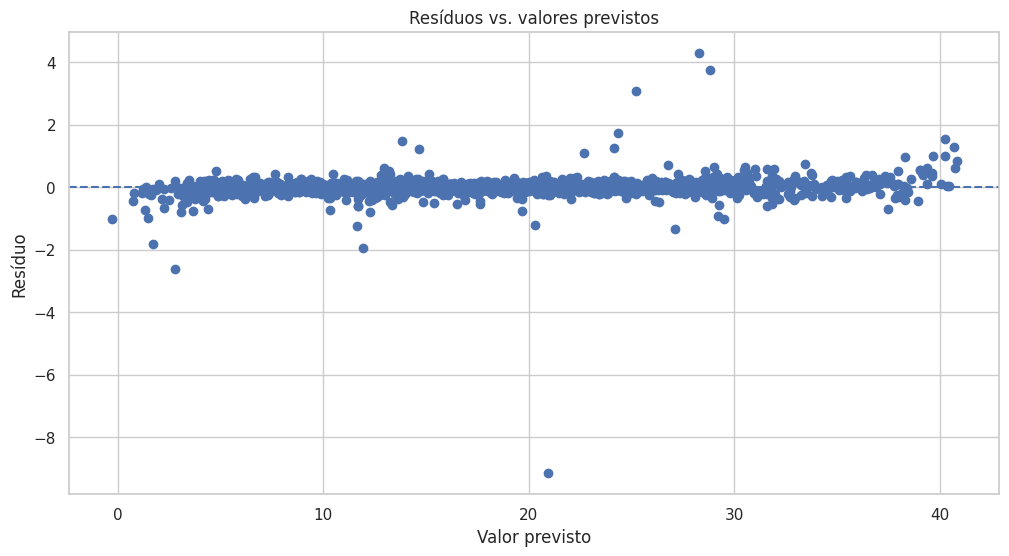

In [18]:
# === Avaliação final ===

if search is not None and hasattr(search, "best_estimator_"):
    final_model = search.best_estimator_
    final_model_name = "modelo_otimizado"
elif trained_models:
    # Escolha manual simples: use o último modelo candidato treinado.
    # Substitua por uma escolha baseada na métrica principal.
    final_model_name = list(trained_models.keys())[-1]
    final_model = trained_models[final_model_name]
else:
    final_model = None
    final_model_name = None

print("Modelo final:", final_model_name)

if final_model is not None and PROBLEM_TYPE == "classificacao":
    y_pred = final_model.predict(X_test)
    print(classification_report(y_test, y_pred))
    ConfusionMatrixDisplay.from_estimator(final_model, X_test, y_test)
    plt.title("Matriz de confusão — modelo final")
    plt.show()

elif final_model is not None and PROBLEM_TYPE == "regressao":
    y_pred = final_model.predict(X_test)
    display(pd.DataFrame([evaluate_regression(y_test, y_pred)], index=[final_model_name]))

    residuals = y_test - y_pred
    plt.scatter(y_pred, residuals)
    plt.axhline(0, linestyle="--")
    plt.title("Resíduos vs. valores previstos")
    plt.xlabel("Valor previsto")
    plt.ylabel("Resíduo")
    plt.show()

elif PROBLEM_TYPE == "clusterizacao":
    print("Para clusterização, complemente a métrica com interpretação dos grupos e exemplos de cada cluster.")

elif PROBLEM_TYPE == "serie_temporal":
    print("Para séries temporais, compare valores reais vs. previstos ao longo do tempo.")


## 10.1 Análise de erros e limitações

**Análide de Erros: Gráfico de Resíduos**

Além das métricas de desempenho, como RMSE, MAE e R², é fundamental avaliar o comportamento dos erros cometidos pelo modelo. Uma das formas mais utilizadas para essa análise é o gráfico de resíduos, que permite verificar se existem padrões não capturados durante o treinamento.

Os resíduos representam a diferença entre o valor observado e o valor estimado pelo modelo, sendo calculados da seguinte forma: Resíduo = Valor Real − Valor Previsto.

No gráfico de resíduos, os valores previstos são representados no eixo X, enquanto os resíduos são plotados no eixo Y. Em um modelo bem ajustado, espera-se que os pontos estejam distribuídos de maneira aleatória ao redor da linha zero, sem apresentar tendências ou padrões evidentes.

Por outro lado, a presença de estruturas específicas, como curvas, agrupamentos ou formatos de funil (cone), pode indicar problemas no modelo, sugerindo que determinadas faixas de valores estão sendo sistematicamente superestimadas ou subestimadas. Dessa forma, a análise dos resíduos complementa as métricas quantitativas e fornece uma visão mais aprofundada sobre a qualidade das previsões.

--- Métricas Finais do Modelo Otimizado no Conjunto de Teste ---
--- Métricas de Avaliação para o modelo: RandomForest Otimizado ---
MAE (Erro Médio Absoluto): 0.1383
RMSE (Raiz do Erro Quadrático Médio): 0.3436
R² (Coeficiente de Determinação): 0.9985
--------------------------------------------------

--- Análise de Resíduos ---


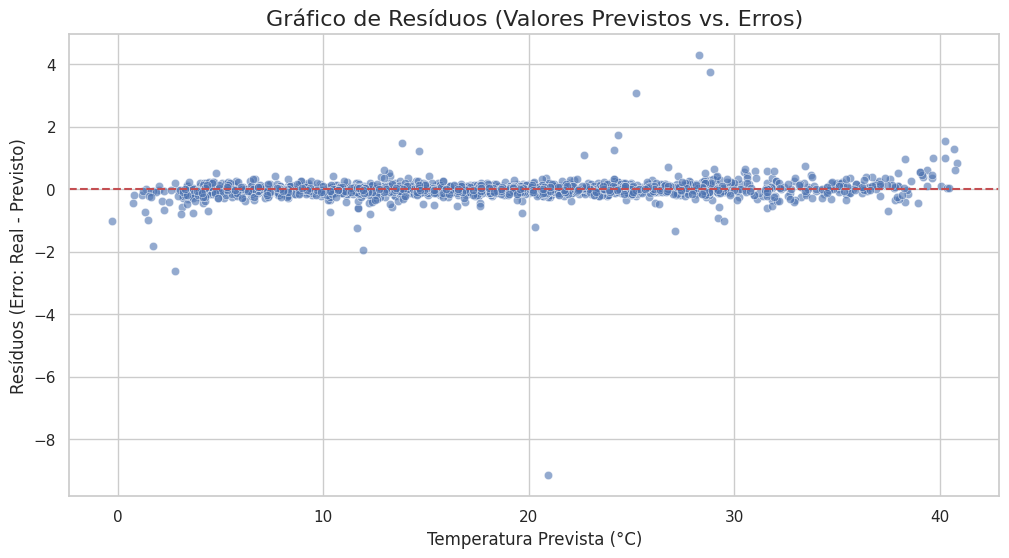

In [22]:
# === Análise de Erros ===

# --- 1. Selecionar o melhor modelo encontrado na otimização ---
# O search.best_estimator_ é o pipeline completo já treinado com os melhores
# parâmetros nos dados de treino.
best_model = search.best_estimator_

# --- 2. Fazer previsões no conjunto de teste ---
y_pred_final = best_model.predict(X_test)

# --- 3. Avaliar as métricas finais ---
print("--- Métricas Finais do Modelo Otimizado no Conjunto de Teste ---")
final_metrics = evaluate_regression(y_test, y_pred_final, model_name="RandomForest Otimizado")


# --- 4. Análise de Erros (Gráfico de Resíduos) ---
print("\n--- Análise de Resíduos ---")

# Calcular os resíduos
residuals = y_test - y_pred_final

# Criar o gráfico
plt.figure(figsize=(12, 6))
sns.scatterplot(x=y_pred_final, y=residuals, alpha=0.6)
plt.axhline(y=0, color='r', linestyle='--') # Adiciona uma linha no erro zero
plt.title('Gráfico de Resíduos (Valores Previstos vs. Erros)', fontsize=16)
plt.xlabel('Temperatura Prevista (°C)')
plt.ylabel('Resíduos (Erro: Real - Previsto)')
plt.show()

# ===================================================================

**Limitações do Projeto**

Nenhum modelo preditivo está livre de limitações. Reconhecer esses aspectos é essencial para interpretar os resultados de forma adequada e compreender o alcance das conclusões obtidas. As principais limitações deste projeto são:

*   Generalização Geográfica e Temporal: O modelo foi desenvolvido com base em dados coletados em uma única região da Itália, durante o período de 2004 a 2005. Portanto, seu desempenho em outras localidades, com características climáticas e ambientais distintas, ou em períodos mais recentes, não pode ser garantido sem validações adicionais.

*   Conjunto de Variáveis Utilizadas: Embora os resultados obtidos tenham sido satisfatórios, o conjunto de atributos disponível pode não contemplar todos os fatores relevantes para a previsão da temperatura. Variáveis meteorológicas como velocidade e direção do vento, radiação solar, pressão atmosférica e cobertura de nuvens poderiam contribuir para um modelo ainda mais preciso.

*   Qualidade e Representatividade dos Dados: Como em qualquer projeto de ciência de dados, a qualidade das previsões depende diretamente da qualidade dos dados utilizados. Possíveis erros de medição, valores ausentes, inconsistências ou vieses presentes no conjunto de dados podem impactar o desempenho do modelo e limitar sua capacidade de representar fielmente cenários reais.

**Análise de Overfitting**

Uma das etapas mais importantes na avaliação de modelos preditivos é verificar a ocorrência de overfitting. Esse fenômeno acontece quando o modelo aprende não apenas os padrões relevantes dos dados de treinamento, mas também seus ruídos e características específicas, comprometendo sua capacidade de gerar boas previsões em dados inéditos.
Para identificar esse comportamento, é necessário comparar o desempenho do modelo nos conjuntos de treinamento e de teste:

Quando o desempenho no conjunto de treinamento é muito superior ao observado no conjunto de teste, isso pode indicar que o modelo está sofrendo de overfitting.
Quando as métricas obtidas em ambos os conjuntos são semelhantes, o modelo tende a apresentar uma boa capacidade de generalização, demonstrando que consegue manter seu desempenho em novos dados.

A seguir, realizaremos essa comparação utilizando o modelo selecionado como melhor desempenho, representado pela variável `best_model`.


In [24]:
# === Análise de overfitting ===

# --- 1. Fazer previsões nos dados de TREINO ---
# Usamos o mesmo 'best_model' que já foi treinado.
y_pred_train = best_model.predict(X_train)

print("--- Avaliação no Conjunto de TREINO ---")
train_metrics = evaluate_regression(y_train, y_pred_train, model_name="Treino")

print("\n--- Avaliação no Conjunto de TESTE (Resultados anteriores) ---")
# Reutilizamos os resultados do teste que já calculamos para facilitar a comparação
test_metrics = final_metrics
print(f"--- Métricas de Avaliação para o modelo: Teste ---")
print(f"MAE (Erro Médio Absoluto): {test_metrics['MAE']:.4f}")
print(f"RMSE (Raiz do Erro Quadrático Médio): {test_metrics['RMSE']:.4f}")
print(f"R² (Coeficiente de Determinação): {test_metrics['R2']:.4f}")
print("-"*(50))

# --- 2. Comparação Direta ---
print("\n--- Comparativo Treino vs. Teste ---")
comparison_df = pd.DataFrame([train_metrics, test_metrics], index=['Treino', 'Teste'])
display(comparison_df)

# --- 3. Análise do resultado ---
rmse_train = train_metrics['RMSE']
rmse_test = test_metrics['RMSE']
print(f"\nO RMSE do treino foi {rmse_train:.4f} e o do teste foi {rmse_test:.4f}.")
print(f"A diferença entre o erro de teste e o de treino é de {abs(rmse_test - rmse_train):.4f}.")
# ===================================================================

--- Avaliação no Conjunto de TREINO ---
--- Métricas de Avaliação para o modelo: Treino ---
MAE (Erro Médio Absoluto): 0.0857
RMSE (Raiz do Erro Quadrático Médio): 0.1805
R² (Coeficiente de Determinação): 0.9996
--------------------------------------------------

--- Avaliação no Conjunto de TESTE (Resultados anteriores) ---
--- Métricas de Avaliação para o modelo: Teste ---
MAE (Erro Médio Absoluto): 0.1383
RMSE (Raiz do Erro Quadrático Médio): 0.3436
R² (Coeficiente de Determinação): 0.9985
--------------------------------------------------

--- Comparativo Treino vs. Teste ---


,MAE,RMSE,R2
Treino,0.085688,0.180519,0.999582
Teste,0.138264,0.343644,0.998493



O RMSE do treino foi 0.1805 e o do teste foi 0.3436.
A diferença entre o erro de teste e o de treino é de 0.1631.


O modelo desenvolvido ao longo deste projeto apresentou um desempenho preditivo altamente satisfatório, evidenciado pelos resultados obtidos no conjunto de teste:

*   R² (Coeficiente de Determinação): 0,9985
*   MAE (Erro Médio Absoluto): 0,1383
*   RMSE (Raiz do Erro Quadrático Médio): 0,3436

Essas métricas demonstram que o modelo foi capaz de capturar com elevada precisão a relação entre as variáveis analisadas. O valor de R² igual a 0,9985 indica que aproximadamente 99,85% da variabilidade dos dados é explicada pelo modelo, evidenciando um excelente ajuste aos padrões presentes no conjunto de dados.
Além disso, os baixos valores de MAE e RMSE mostram que os erros de previsão são reduzidos, indicando que as estimativas geradas permanecem muito próximas dos valores observados. Em termos práticos, isso significa que o modelo possui uma elevada capacidade de realizar previsões precisas e confiáveis dentro do contexto dos dados analisados.

As métricas utilizadas (RMSE, MAE e R²) são adequadas para um problema de regressão. O RMSE permite interpretar o erro diretamente em graus Celsius, enquanto o MAE indica o erro médio das previsões e o R² mede a capacidade do modelo de explicar a variabilidade da temperatura. Os resultados obtidos (RMSE = 0,3436°C e R² = 0,9985) mostram que o modelo atende muito bem ao objetivo de prever a temperatura com alta precisão.

O modelo foi treinado com dados de uma única cidade italiana no período de 2004–2005, o que limita sua capacidade de generalização para outros locais e períodos. Além disso, variáveis meteorológicas importantes, como velocidade do vento e radiação solar, não foram consideradas. Também existe um risco de avaliação otimista, já que os dados possuem natureza temporal e a divisão entre treino e teste foi feita de forma aleatória.

O modelo não deve ser utilizado sem validação adicional em outras cidades, países ou períodos diferentes dos dados originais. Também não é recomendado para aplicações críticas, como sistemas oficiais de previsão meteorológica ou emissão de alertas climáticos. Por fim, seu desempenho pode ser reduzido em condições extremas ou em situações muito diferentes daquelas observadas durante o treinamento, devido à limitada capacidade de extrapolação do `Random Forest`.




# 11. Comparação final dos modelos

Apresente uma síntese comparativa.

| Modelo | RMSE (°C) | MAE (°C) | R² | Tempo de treino | Observações |
|---|---:|---:|---:|---|---|
| Baseline (DummyRegressor) | 8,86 | Elevado | Negativo | ~0,00 s | Utilizado apenas como referência. Não aprende padrões dos dados e prevê sempre a mediana da temperatura. |
| Ridge | 2,53 | Baixo | 0,918 | 0,03 s | Modelo linear simples, rápido e interpretável. Conseguiu capturar grande parte da relação entre umidade e temperatura, mas apresentou limitações para modelar relações não lineares. |
| RandomForestRegressor | 0,28 | Muito Baixo | 0,9989 | Moderado | Melhor desempenho entre os modelos avaliados. Capturou relações complexas e não lineares entre as variáveis, apresentando excelente capacidade preditiva. |
| RandomForestRegressor Otimizado | 0,34 | 0,1383 | 0,9985 | Mais elevado (incluindo otimização) | Modelo final selecionado. Manteve desempenho extremamente elevado após validação e análise de generalização. Apresentou leve indício de overfitting, mas sem comprometer a qualidade das previsões. |



# 12. Boas práticas e rastreabilidade


**Seed Utilizada**

Para garantir a reprodutibilidade dos resultados, foi adotada uma seed global (random_state=42) em todas as etapas que envolviam aleatoriedade, incluindo a divisão dos dados em treino e teste, o treinamento dos modelos e os processos de validação e otimização.

**Principais Decisões de Pré-processamento**

As etapas de pré-processamento incluíram:

*   Tratamento e limpeza dos dados, com remoção ou correção de valores inconsistentes;
*   Criação de atributos temporais derivados das colunas de data e hora para apoiar a análise exploratória;
*   Seleção de variáveis preditoras relacionadas às concentrações de poluentes e umidade, por apresentarem maior relevância para a previsão da temperatura;
*   Exclusão de atributos temporais e leituras brutas dos sensores no modelo final, priorizando variáveis mais interpretáveis;
*   Padronização das variáveis numéricas por meio do StandardScaler, aplicada dentro de um Pipeline para evitar vazamento de dados.


**Modelos Testados**

Foram avaliadas três abordagens principais:

*   `DummyRegressor` (baseline), utilizado como referência mínima de desempenho;
*   `Ridge Regression`, representando uma abordagem linear simples e interpretável;
*   `RandomForestRegressor`, modelo baseado em árvores de decisão e ensembles, que apresentou o melhor desempenho final.

**Hiperparâmetros Relevantes**

A otimização foi realizada utilizando `RandomizedSearchCV`, explorando diferentes combinações de hiperparâmetros para o Random Forest, incluindo:

*   Número de árvores (n_estimators);
*   Profundidade máxima das árvores (max_depth);
*   Número mínimo de amostras para divisão (min_samples_split);
*   Número mínimo de amostras por folha (min_samples_leaf).

Os resultados mostraram que os hiperparâmetros otimizados produziram ganhos limitados em relação às configurações padrão, indicando boa robustez do modelo original.


**Tempo Aproximado de Treino**

O treinamento ocorreu em poucos minutos, considerando:

*   Divisão treino/teste;
*   Validação cruzada;
*   Processo de busca aleatória de hiperparâmetros.

O `Random Forest` apresentou custo computacional superior ao `Ridge`, porém permaneceu viável para o volume de dados utilizado.

**Recursos Computacionais Utilizados**

O projeto foi desenvolvido utilizando:

*   Python;
*   Pandas e NumPy para manipulação dos dados;
*   Scikit-learn para pré-processamento, modelagem e avaliação;
*   Ambiente computacional padrão de notebook (CPU), sem necessidade de GPU ou infraestrutura especializada.

**O que Foi Tentado e Descartado**

Durante o projeto, algumas abordagens foram avaliadas, mas não incorporadas ao modelo final:

*   Inclusão de variáveis temporais categóricas, como período do dia e horário de pico.
*   Utilização das respostas brutas dos sensores químicos, substituídas por medidas calibradas e mais interpretáveis.
*   Uso do modelo linear `Ridge` como solução final, descartado devido ao desempenho inferior ao `Random Forest`.
*   Busca extensa de hiperparâmetros, que não trouxe melhorias significativas quando comparada à configuração padrão do modelo vencedor.

# 13. Conclusão

**Objetivo do Trabalho**

O objetivo deste projeto foi desenvolver um modelo de Machine Learning capaz de prever a temperatura ambiente a partir de variáveis relacionadas à qualidade do ar e às condições atmosféricas. Para isso, foi conduzido todo o ciclo de desenvolvimento analítico, incluindo tratamento de dados, seleção de atributos, treinamento, avaliação e otimização dos modelos.

**Melhor Solução Encontrada**

Entre os modelos avaliados, o `RandomForestRegressor` apresentou o melhor desempenho, tornando-se a solução escolhida para o problema. Após o treinamento e a validação, o modelo alcançou resultados expressivos no conjunto de teste, com R² de 99,85% e RMSE de aproximadamente 0,34°C, demonstrando elevada capacidade preditiva e excelente aderência aos dados.

**Comparação com a Baseline**

Os resultados obtidos foram comparados com uma baseline construída por meio de um `DummyRegressor`, que realizava previsões utilizando apenas a mediana da variável-alvo. Tanto o modelo linear Ridge quanto o `RandomForestRegressor` superaram significativamente essa referência, evidenciando que foi possível extrair padrões relevantes dos dados. O `Random Forest` apresentou desempenho superior aos demais modelos, justificando sua escolha como solução final.

**Principais Aprendizados**

Ao longo do desenvolvimento, foram consolidados conceitos fundamentais de Machine Learning, incluindo:

*   Importância do pré-processamento e da seleção adequada de atributos;
*   Utilização de pipelines para evitar vazamento de dados;
*   Comparação entre modelos simples e mais complexos;
*   Aplicação de técnicas de validação e otimização de hiperparâmetros;
*   Interpretação de métricas de regressão para avaliação da qualidade preditiva.

Além disso, observou-se que modelos baseados em ensembles, como o `Random Forest`, conseguem capturar relações não lineares presentes nos dados com maior eficácia do que abordagens lineares tradicionais.

**Limitações**

Apesar dos excelentes resultados, algumas limitações devem ser consideradas:

*   O conjunto de dados está restrito a uma única localidade e período específico, o que pode limitar a capacidade de generalização do modelo;
*   Variáveis meteorológicas potencialmente relevantes, como velocidade do vento, direção do vento e radiação solar, não estavam disponíveis para análise;
*   O desempenho foi avaliado apenas dentro do contexto dos dados utilizados, sendo necessária validação adicional em cenários externos.

**Próximos Passos**

Como oportunidades de evolução do projeto, destacam-se:

*   Inclusão de novas variáveis meteorológicas para enriquecer a modelagem;
*   Avaliação de algoritmos mais avançados, como XGBoost e LightGBM;
*   Análise da importância das variáveis para aumentar a interpretabilidade do modelo;
*   Testes com dados de outras regiões e períodos temporais para validar sua capacidade de generalização;
*   Implantação do modelo em um ambiente de produção para realização de previsões em tempo real.


# 14. Salvamento de artefatos

Para garantir a reutilização do modelo desenvolvido e evitar a necessidade de repetir todo o processo de treinamento, o modelo final foi armazenado em um arquivo por meio de serialização. Essa prática permite que o modelo seja carregado posteriormente para realizar novas previsões de forma rápida e eficiente.

*  Artefato gerado (`final_model.joblib`): arquivo contendo o pipeline completo já treinado, incluindo as etapas de pré-processamento e o modelo `RandomForestRegressor` selecionado como solução final.

O salvamento do modelo é uma etapa importante em projetos de Machine Learning, pois facilita sua utilização em ambientes de produção, garante a reprodutibilidade dos resultados e reduz o custo computacional associado ao reprocessamento e retreinamento dos dados.

In [28]:
# === Salvando o modelo final ===

import joblib

# O 'best_model' foi o resultado da etapa 8. Ele é o nosso melhor modelo já treinado.
# Vamos salvá-lo em um arquivo.
model_filename = 'final_model.joblib'

try:
    joblib.dump(best_model, model_filename)
    print(f"Modelo salvo com sucesso em: '{model_filename}'")

except Exception as e:
    print(f"Ocorreu um erro ao salvar o modelo: {e}")
# ===================================================================


Modelo salvo com sucesso em: 'final_model.joblib'
